# Distance-dependent connection probability model of a connectivity matrix

Notebook based on: https://github.com/openbraininstitute/connectome-analysis/blob/master/tutorials/modelling.ipynb

In [1]:
import pandas as pd
import pickle
import numpy as np
from scipy.spatial import distance

import conntility as conn
from connalysis import modelling
from connalysis import randomization 
from connalysis.network import classic as nxc
import matplotlib.pyplot as plt 

In [2]:
# Let's see firts what the code does for just one connectivity matrix
root_path = "/Users/natalibarroszulaica/Desktop/OBI/HUMAN_CORTEX/PAPERS_ON_GOING/CONNECTIVITY_PAPER/code/conn_matrix/"

# Loading data connectivity matrix, for example: human ATC
mat_name = "Human_NEWstruct_conmat_filtered_compressed"
file_name = "Human_NEWstruct_conmat_filtered_compressed.h5"
M = conn.ConnectivityMatrix.from_h5(f"{root_path}{file_name}")

print(f"Number of nodes in the matrix {len(M.vertices)}")

# Formating data 
adj = M.matrix.astype('bool').tocsr()
N = adj.shape[0]
nrn_info = M.vertices

Number of nodes in the matrix 20064


# Looking at distance values to choose modelling paramaters for one example

suggested bin size =  94


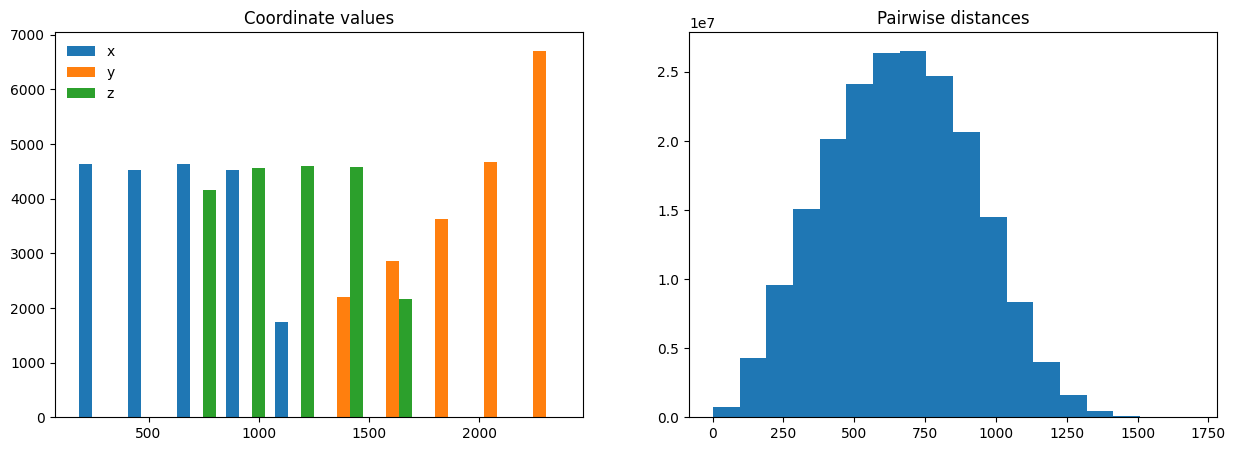

In [3]:
# Meta parameters of the model 
no_bins = 18 #for human and control: no_bins=18  # for rat: no_bins = 15

dists=distance.pdist(nrn_info[['x', 'y', 'z']])
fig, axs = plt.subplots(1,2, figsize=(15,5))
axs[0].hist(nrn_info[['x', 'y', 'z']], label=['x', 'y', 'z'])
axs[0].legend(frameon=False)
axs[0].set_title("Coordinate values")
_, dist_bins, _=axs[1].hist(dists, no_bins)
axs[1].set_title("Pairwise distances")

#Suggested bin_size
bin_size=int(dist_bins[1]-dist_bins[0])

print('suggested bin size = ', bin_size)

Text(0.5, 1.0, 'Pairwise distances')

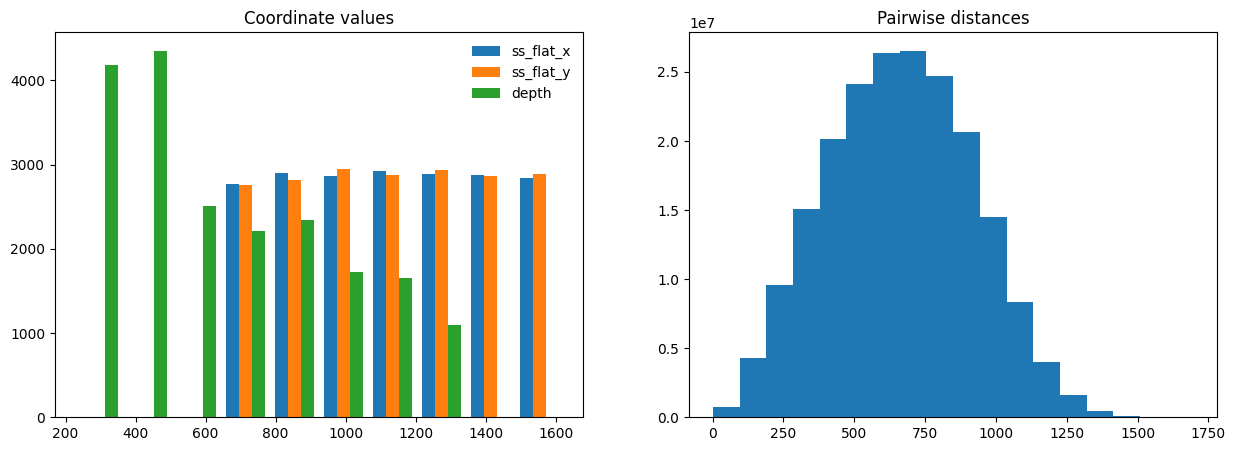

In [4]:
# flat coordinades
dists = distance.pdist(nrn_info[['ss_flat_x', 'ss_flat_y', 'depth']])
fig, axs = plt.subplots(1,2, figsize=(15,5))
axs[0].hist(nrn_info[['ss_flat_x', 'ss_flat_y', 'depth']], label=['ss_flat_x', 'ss_flat_y', 'depth'])
axs[0].legend(frameon=False)
axs[0].set_title("Coordinate values")
_, dist_bins, _=axs[1].hist(dists, no_bins)
axs[1].set_title("Pairwise distances")

## Building model

In [5]:
# Configure model building
config_dict = {'model_name': f'2Dist_model{mat_name}',  # Name of the model (to be used in file names, ...)
               'model_order': 2,                        # Model order
               'coord_names': ['x', 'y', 'z'],          # name of coordinates in nrn_info data frame
               'bin_size_um': bin_size,                 # Bin size (µm) for depth binning
               'max_range_um': 1460,                    # Max. distance (µm) range to consider (None to usefull distance range) #1190 µm for rat #1460 for human
               'sample_size': None,                     # Size of random subset of neurons to consider (0 or None to disable subsampling)
               'sample_seed': None,                     # Seed for selecting random subset of neurons
               'model_dir': f'results/',                # Output directory where to save the model (None to disable saving)
               'data_dir': f'results/',                 # Output directory where to save the extracted data (None to disable saving)
               'do_plot': True,                         # Enable/disable output plotting
               'plot_dir': 'results/figs',              # Output directory where to save the plots (None to disable saving)
               'N_split': None,                         # Number of data splits to sequentially run computations on, reducing memory consumption (None to disable splitting)
               'part_idx': None}  

 2025-05-19 17:05:51,182: Running order-2 model building {'coord_names': ['x', 'y', 'z'], 'bin_size_um': 94, 'max_range_um': 1460, 'sample_size': None, 'sample_seed': None, 'model_dir': 'results/', 'data_dir': 'results/', 'do_plot': True, 'plot_dir': 'results/figs', 'N_split': None, 'part_idx': None}...
 2025-05-19 17:05:52,195: Extracting 1-dimensional (16) connection probabilities...
100% |##############################################################################################################################|
 2025-05-19 17:06:23,871: Pickled dict written to results/2Dist_modelHuman_NEWstruct_conmat_filtered_compressed__data.pickle
 2025-05-19 17:06:23,872: MODEL FIT: f(x) = 0.952021 * exp(-0.004185 * x)
 2025-05-19 17:06:23,872: Pickled dict written to results/2Dist_modelHuman_NEWstruct_conmat_filtered_compressed__model.pickle
 2025-05-19 17:06:24,151: Figure saved to /Users/natalibarroszulaica/Desktop/OBI/HUMAN_CORTEX/PAPERS_ON_GOING/CONNECTIVITY_PAPER/code/ConnectomeUtilitie

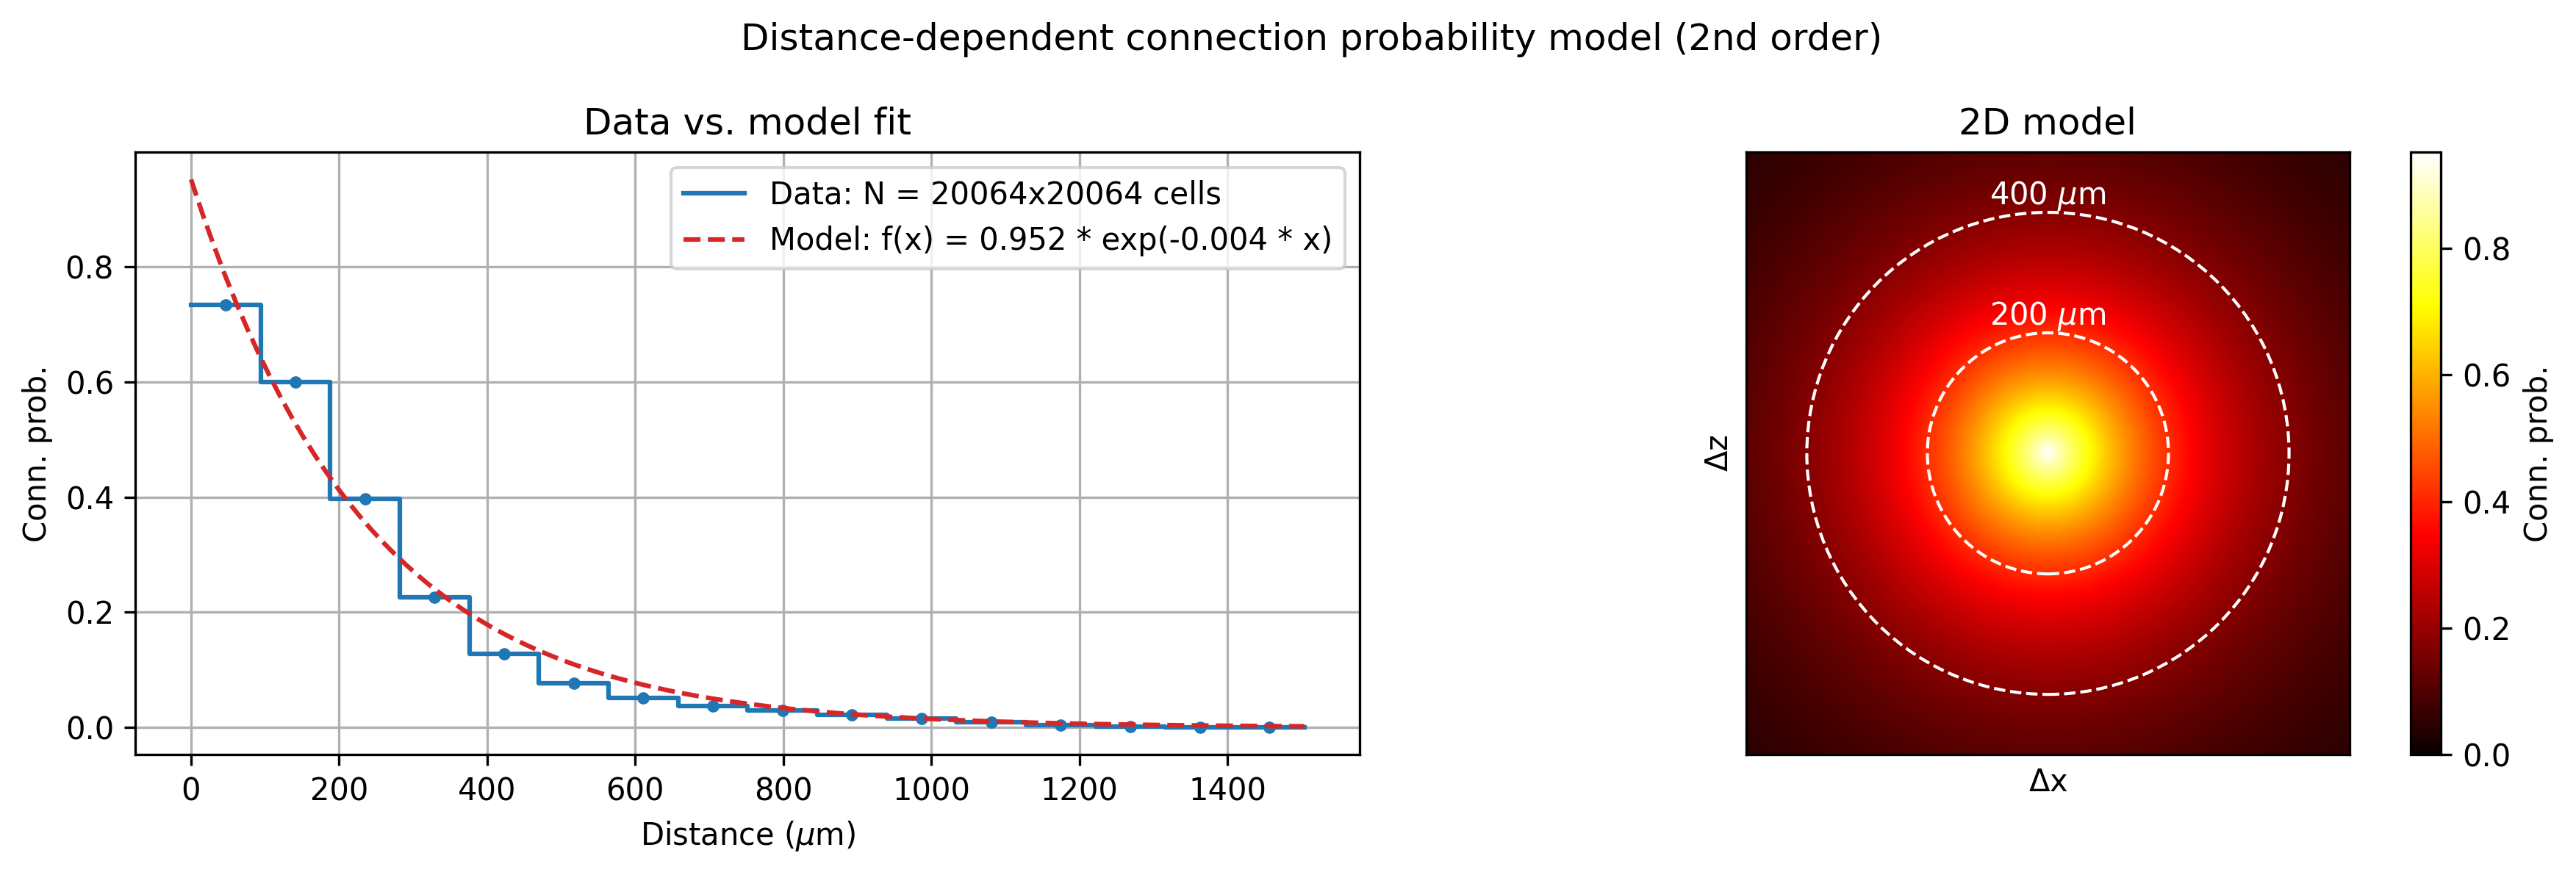

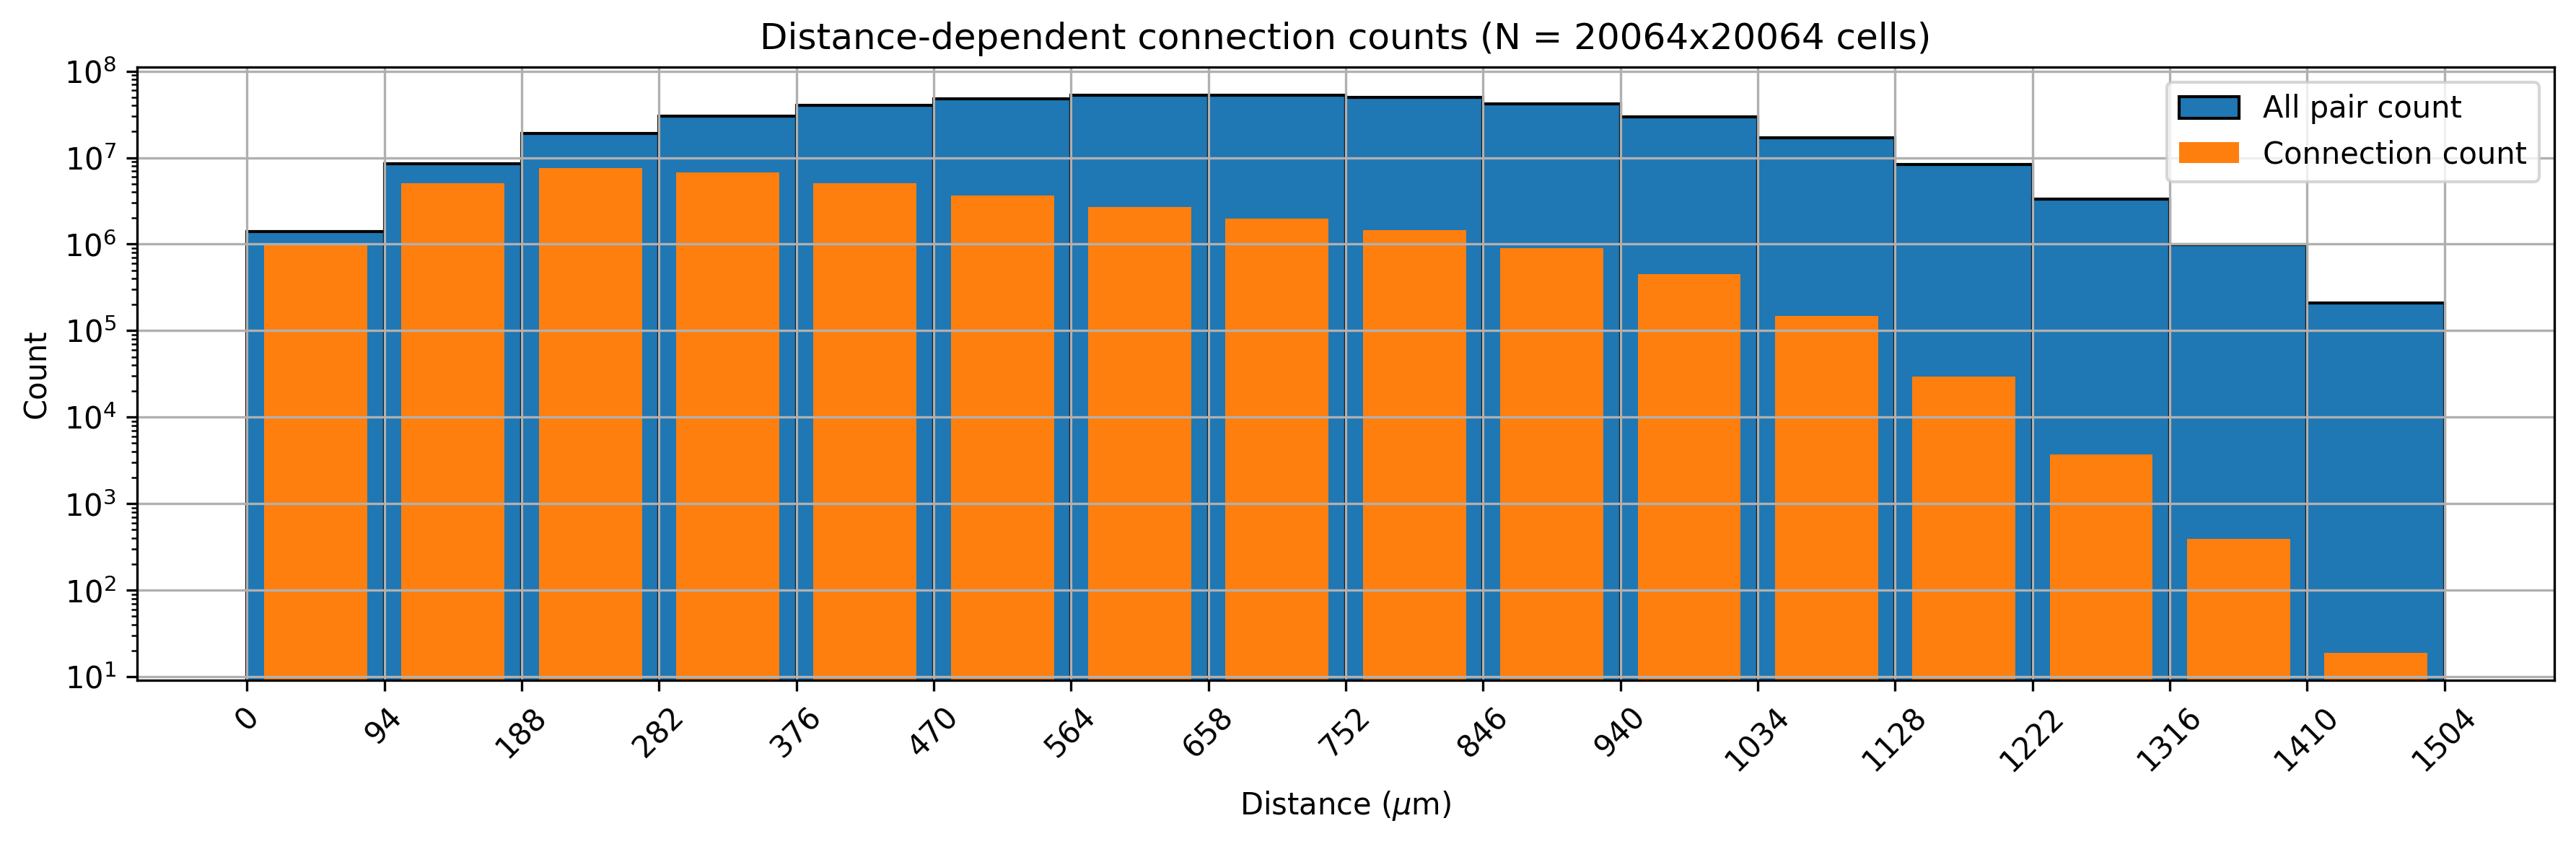

In [6]:
# Build model 
model_results=modelling.run_model_building(adj, nrn_info, **config_dict)

### Interesting values to populate "ConnectionProbability_results.csv" table

In [7]:
exp_model_scale = model_results[1]["model_params"]["exp_model_scale"]
exp_model_exponent = model_results[1]["model_params"]["exp_model_exponent"]

count_all = model_results[0]["count_all"]
count_conn = model_results[0]["count_conn"]
dist_bins = model_results[0]["dist_bins"]

print('circuit name:', mat_name)
print('exp_model_scale:', exp_model_scale)
print('exp_model_exponent:', exp_model_exponent)
print('count_all:', count_all)
print('count_conn:', count_conn)
print('dist_bins:', dist_bins)

circuit name: Human_NEWstruct_conmat_filtered_compressed
exp_model_scale: 0.9520212166053698
exp_model_exponent: 0.004184513325366615
count_all: [ 1406298  8431382 18933300 29944852 40025208 47950646 52499696 53007540
 49520330 41573854 29349074 17072928  8303034  3302972   983368   207842]
count_conn: [1032026 5059762 7523835 6769297 5097834 3673707 2661337 1985333 1456808
  897925  446408  147225   29512    3708     392      19]
dist_bins: [   0   94  188  282  376  470  564  658  752  846  940 1034 1128 1222
 1316 1410 1504]


#### Now we will do the same, but in a loop over all the connectivity matrices

#### For the purpose of plotting we created a csv file with the required values with the results for all connectivity matrices that will be used in another notebook

In [14]:
# Save connectivity matrices in Ms dictionary and load them
root_path = "/Users/natalibarroszulaica/Desktop/OBI/HUMAN_CORTEX/PAPERS_ON_GOING/CONNECTIVITY_PAPER/code/conn_matrix/"

fns = {
    "ATC_human": root_path + "Human_NEWstruct_conmat_filtered_compressed.h5",
    "CPC_human": root_path + "Human_NEWfunct_conmat_filtered_compressed.h5",
    "E_to_T_human": root_path + "Human_pruned_E_to_T_conmat.h5",
    "T_to_T_human": root_path + "Human_pruned_T_to_T_conmat.h5",
    "E_to_E_human": root_path + "Human_pruned_E_to_E_conmat.h5",
    "T_to_E_human": root_path + "Human_pruned_T_to_E_conmat.h5",
    "ATC_rat": root_path + "Rat_623um_squared_struc_conmat_filtered_compressed.h5",
    "CPC_rat": root_path + "Rat_623um_squared_funct_conmat_filtered_compressed.h5",
    "E_to_T_rat": root_path + "Rat_pruned_E_to_T_conmat.h5",
    "T_to_T_rat": root_path + "Rat_pruned_T_to_T_conmat.h5",
    "E_to_E_rat": root_path + "Rat_pruned_E_to_E_conmat.h5",
    "T_to_E_rat": root_path + "Rat_pruned_T_to_E_conmat.h5",
    "HC_RD": root_path + "humanized_rat_pruned_E_to_T_conmat.h5",
    "E_to_T_HC_RD": root_path + "humanized_rat_pruned_E_to_T_conmat.h5",
    "T_to_T_HC_RD": root_path + "humanized_rat_pruned_T_to_T_conmat.h5",
    "E_to_E_HC_RD": root_path + "humanized_rat_pruned_E_to_E_conmat.h5",
    "T_to_E_HC_RD": root_path + "humanized_rat_pruned_T_to_E_conmat.h5"
}

Ms = dict([(k, conn.ConnectivityMatrix.from_h5(v))
           for k, v in fns.items()])

# Control matrix have a special group_name
Ms["HC_RD"] = conn.ConnectivityMatrix.from_h5(root_path+"third_order_mdl_instances_humanized_rat.h5", "instance1")

In [15]:
# Formating data 
results = {}

Ms_key_list = list(Ms.keys())
for k in Ms_key_list:
    print(k)
    config_dict = {}
    
    adj_mat = Ms[k].matrix.astype('bool').tocsr()
    N = adj_mat.shape[0]
    nrn_info = Ms[k].vertices
    
    if 'rat' in k:
        config_dict = {'model_name': f'2Dist_model{k}',     # Name of the model (to be used in file names, ...)
                   'model_order': 2,                        # Model order
                   'coord_names': ['x', 'y', 'z'],          # name of coordinates in nrn_info data frame
                   'bin_size_um': 79,                       # Bin size (µm) for depth binning
                   'max_range_um': 1190,                    # Max. distance (µm) range to consider (None to usefull distance range) #1190 µm for rat
                   'sample_size': None,                     # Size of random subset of neurons to consider (0 or None to disable subsampling)
                   'sample_seed': None,                     # Seed for selecting random subset of neurons
                   'model_dir': f'results/',                # Output directory where to save the model (None to disable saving)
                   'data_dir': f'results/',                 # Output directory where to save the extracted data (None to disable saving)
                   'do_plot': False,                         # Enable/disable output plotting
                   'plot_dir': 'results/figs',              # Output directory where to save the plots (None to disable saving)
                   'N_split': None,                         # Number of data splits to sequentially run computations on, reducing memory consumption (None to disable splitting)
                   'part_idx': None} 
    else:
        config_dict = {'model_name': f'2Dist_model{k}', # Name of the model (to be used in file names, ...)
               'model_order': 2,                        # Model order
               'coord_names': ['x', 'y', 'z'],          # name of coordinates in nrn_info data frame
               'bin_size_um': 94,                       # Bin size (µm) for depth binning
               'max_range_um': 1460,                    # Max. distance (µm) range to consider (None to usefull distance range) #1190 µm for rat
               'sample_size': None,                     # Size of random subset of neurons to consider (0 or None to disable subsampling)
               'sample_seed': None,                     # Seed for selecting random subset of neurons
               'model_dir': f'results/',                # Output directory where to save the model (None to disable saving)
               'data_dir': f'results/',                 # Output directory where to save the extracted data (None to disable saving)
               'do_plot': False,                         # Enable/disable output plotting
               'plot_dir': 'results/figs',              # Output directory where to save the plots (None to disable saving)
               'N_split': None,                         # Number of data splits to sequentially run computations on, reducing memory consumption (None to disable splitting)
               'part_idx': None}  

    
    model_results = modelling.run_model_building(adj_mat, nrn_info, **config_dict)
    results[k] = model_results

ATC_human


 2025-05-19 17:12:40,791: Running order-2 model building {'coord_names': ['x', 'y', 'z'], 'bin_size_um': 94, 'max_range_um': 1460, 'sample_size': None, 'sample_seed': None, 'model_dir': 'results/', 'data_dir': 'results/', 'do_plot': False, 'plot_dir': 'results/figs', 'N_split': None, 'part_idx': None}...
 2025-05-19 17:12:42,527: Extracting 1-dimensional (16) connection probabilities...
100% |##############################################################################################################################|
 2025-05-19 17:13:14,158: Pickled dict written to results/2Dist_modelATC_human__data.pickle
 2025-05-19 17:13:14,159: MODEL FIT: f(x) = 0.952021 * exp(-0.004185 * x)
 2025-05-19 17:13:14,159: Pickled dict written to results/2Dist_modelATC_human__model.pickle


CPC_human


 2025-05-19 17:13:14,693: Running order-2 model building {'coord_names': ['x', 'y', 'z'], 'bin_size_um': 94, 'max_range_um': 1460, 'sample_size': None, 'sample_seed': None, 'model_dir': 'results/', 'data_dir': 'results/', 'do_plot': False, 'plot_dir': 'results/figs', 'N_split': None, 'part_idx': None}...
 2025-05-19 17:13:15,539: Extracting 1-dimensional (16) connection probabilities...
100% |##############################################################################################################################|
 2025-05-19 17:13:42,158: Pickled dict written to results/2Dist_modelCPC_human__data.pickle
 2025-05-19 17:13:42,158: MODEL FIT: f(x) = 0.333778 * exp(-0.008022 * x)
 2025-05-19 17:13:42,159: Pickled dict written to results/2Dist_modelCPC_human__model.pickle


E_to_T_human


...

 2025-05-19 17:20:18,690: Running order-2 model building {'coord_names': ['x', 'y', 'z'], 'bin_size_um': 94, 'max_range_um': 1460, 'sample_size': None, 'sample_seed': None, 'model_dir': 'results/', 'data_dir': 'results/', 'do_plot': False, 'plot_dir': 'results/figs', 'N_split': None, 'part_idx': None}...
 2025-05-19 17:20:19,547: Extracting 1-dimensional (16) connection probabilities...
100% |##############################################################################################################################|
 2025-05-19 17:20:48,149: Pickled dict written to results/2Dist_modelT_to_T_HC_RD__data.pickle
 2025-05-19 17:20:48,150: MODEL FIT: f(x) = 0.181767 * exp(-0.003784 * x)
 2025-05-19 17:20:48,151: Pickled dict written to results/2Dist_modelT_to_T_HC_RD__model.pickle


E_to_E_HC_RD


 2025-05-19 17:20:48,419: Running order-2 model building {'coord_names': ['x', 'y', 'z'], 'bin_size_um': 94, 'max_range_um': 1460, 'sample_size': None, 'sample_seed': None, 'model_dir': 'results/', 'data_dir': 'results/', 'do_plot': False, 'plot_dir': 'results/figs', 'N_split': None, 'part_idx': None}...
 2025-05-19 17:20:49,323: Extracting 1-dimensional (16) connection probabilities...
100% |##############################################################################################################################|
 2025-05-19 17:21:16,780: Pickled dict written to results/2Dist_modelE_to_E_HC_RD__data.pickle
 2025-05-19 17:21:16,780: MODEL FIT: f(x) = 0.041170 * exp(-0.002909 * x)
 2025-05-19 17:21:16,781: Pickled dict written to results/2Dist_modelE_to_E_HC_RD__model.pickle


T_to_E_HC_RD


 2025-05-19 17:21:17,052: Running order-2 model building {'coord_names': ['x', 'y', 'z'], 'bin_size_um': 94, 'max_range_um': 1460, 'sample_size': None, 'sample_seed': None, 'model_dir': 'results/', 'data_dir': 'results/', 'do_plot': False, 'plot_dir': 'results/figs', 'N_split': None, 'part_idx': None}...
 2025-05-19 17:21:18,003: Extracting 1-dimensional (16) connection probabilities...
100% |##############################################################################################################################|
 2025-05-19 17:21:45,306: Pickled dict written to results/2Dist_modelT_to_E_HC_RD__data.pickle
 2025-05-19 17:21:45,307: MODEL FIT: f(x) = 0.062629 * exp(-0.003837 * x)
 2025-05-19 17:21:45,307: Pickled dict written to results/2Dist_modelT_to_E_HC_RD__model.pickle


In [16]:
# Let's see the structure of the data for one matrix
results['ATC_human']

({'p_conn_dist': array([7.33860106e-01, 6.00110634e-01, 3.97386351e-01, 2.26058790e-01,
         1.27365584e-01, 7.66143380e-02, 5.06924269e-02, 3.74537849e-02,
         2.94183823e-02, 2.15983103e-02, 1.52102925e-02, 8.62330117e-03,
         3.55436338e-03, 1.12262532e-03, 3.98630014e-04, 9.14155945e-05]),
  'count_conn': array([1032026, 5059762, 7523835, 6769297, 5097834, 3673707, 2661337,
         1985333, 1456808,  897925,  446408,  147225,   29512,    3708,
             392,      19]),
  'count_all': array([ 1406298,  8431382, 18933300, 29944852, 40025208, 47950646,
         52499696, 53007540, 49520330, 41573854, 29349074, 17072928,
          8303034,  3302972,   983368,   207842]),
  'dist_bins': array([   0,   94,  188,  282,  376,  470,  564,  658,  752,  846,  940,
         1034, 1128, 1222, 1316, 1410, 1504])},
 {'model': 'exp_model_scale * np.exp(-exp_model_exponent * np.array(d))',
  'model_inputs': ['d'],
  'model_params': {'exp_model_scale': 0.9520212166053698,
   'exp_m

In [17]:
# safe data into pandas dataframe
df = pd.DataFrame(results)

# safe dataframe into a csv file
df.to_csv('connection_probability_results.csv', index=False)

In [18]:
# Explore the dataframe to get the interested values.

count_conn = df['ATC_human'][0]['count_conn']
count_all = df['ATC_human'][0]['count_all']
dist_bins = df['ATC_human'][0]['dist_bins']
model_scale = df['ATC_human'][1]['model_params']['exp_model_scale']
model_exp = df['ATC_human'][1]['model_params']['exp_model_exponent']